In [1]:
import pandas as pd
import matplotlib.pyplot as plt

df = pd.read_csv("dados_passos_met_eng.csv")

In [2]:
df

,pessoa,contagem_manual,contagem_digital,distancia_digital,dispositivo_contagem,aplicativo_contagem,distancia_real
0,samuel,164,159,130.0,samsung galaxy fit 3,nativo samsung,130.8
1,samuel,155,154,130.0,samsung galaxy fit 3,nativo samsung,130.8
2,samuel,156,145,130.0,samsung galaxy fit 3,nativo samsung,130.8
3,samuel,162,151,130.0,samsung galaxy fit 3,nativo samsung,130.8
4,samuel,79,68,60.0,samsung galaxy fit 3,nativo samsung,63.0
...,...,...,...,...,...,...,...
61,joao,115,118,80.8,iphone 16,stepapp,84.0
62,joao,175,176,123.0,iphone 16,stepapp,130.8
63,joao,173,172,119.0,iphone 16,stepapp,130.8
64,joao,162,166,121.6,iphone 16,stepapp,130.8


<Axes: title={'center': 'Contagem Digital vs Contagem Manual'}, xlabel='contagem_digital', ylabel='contagem_manual'>

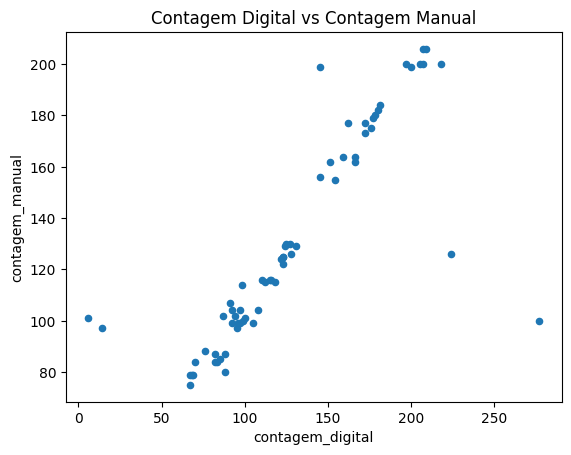

In [3]:
df.plot(x="contagem_digital", y="contagem_manual", kind="scatter", title="Contagem Digital vs Contagem Manual")

In [4]:
adf = df.copy()

adf["diferenca_passos"] = adf["contagem_digital"] - adf["contagem_manual"]
adf["diferenca_abs_passos"] = adf["diferenca_passos"].abs()
adf["disp+app"] = adf["dispositivo_contagem"] + " - " + adf["aplicativo_contagem"]

adf = adf[adf["diferenca_abs_passos"] < 20]

adf.head()

,pessoa,contagem_manual,contagem_digital,distancia_digital,dispositivo_contagem,aplicativo_contagem,distancia_real,diferenca_passos,diferenca_abs_passos,disp+app
0,samuel,164,159,130.0,samsung galaxy fit 3,nativo samsung,130.8,-5,5,samsung galaxy fit 3 - nativo samsung
1,samuel,155,154,130.0,samsung galaxy fit 3,nativo samsung,130.8,-1,1,samsung galaxy fit 3 - nativo samsung
2,samuel,156,145,130.0,samsung galaxy fit 3,nativo samsung,130.8,-11,11,samsung galaxy fit 3 - nativo samsung
3,samuel,162,151,130.0,samsung galaxy fit 3,nativo samsung,130.8,-11,11,samsung galaxy fit 3 - nativo samsung
4,samuel,79,68,60.0,samsung galaxy fit 3,nativo samsung,63.0,-11,11,samsung galaxy fit 3 - nativo samsung


In [5]:
import numpy as np

# Base de analise enriquecida
base = adf.copy()

# Unidade experimental de "passos": media do comprimento do passo observada no experimento
# (distancia real dividida pela contagem manual de passos)
base["comprimento_passo_m"] = base["distancia_real"] / base["contagem_manual"]
passo_medio_experimental_m = base["comprimento_passo_m"].mean()
base["passos_equivalentes"] = base["distancia_real"] / passo_medio_experimental_m

# Resumo geral da precisao dos medidores digitais
resumo_geral_precisao = pd.DataFrame(
    [
        {
            "n_registros": len(base),
            "n_pessoas": base["pessoa"].nunique(),
            "n_dispositivos": base["dispositivo_contagem"].nunique(),
            "n_aplicativos": base["aplicativo_contagem"].nunique(),
            "passo_medio_experimental_m": passo_medio_experimental_m,
            "erro_medio_signed_passos": base["diferenca_passos"].mean(),
            "erro_medio_abs_passos": base["diferenca_abs_passos"].mean(),
            "erro_mediano_abs_passos": base["diferenca_abs_passos"].median(),
            "rmse_passos": np.sqrt((base["diferenca_passos"] ** 2).mean()),
            "desvio_padrao_erro_passos": base["diferenca_passos"].std(),
            "mape_%": (base["diferenca_abs_passos"] / base["contagem_manual"] * 100).mean(),
            "precisao_relativa_media_%": (1 - (base["diferenca_abs_passos"] / base["contagem_manual"])).mean() * 100,
            "acerto_ate_1_passo_%": (base["diferenca_abs_passos"] <= 1).mean() * 100,
            "acerto_ate_3_passos_%": (base["diferenca_abs_passos"] <= 3).mean() * 100,
            "acerto_ate_5_passos_%": (base["diferenca_abs_passos"] <= 5).mean() * 100,
            "resolucao_observada_passos": base["contagem_digital"].diff().abs().replace(0, np.nan).min(),
        }
    ]
)

# Resumo por dispositivo
resumo_por_dispositivo = {}
for dispositivo, dados_dispositivo in base.groupby("dispositivo_contagem"):
    resumo_por_dispositivo[dispositivo] = pd.DataFrame(
        [
            {
                "dispositivo_contagem": dispositivo,
                "n_registros": len(dados_dispositivo),
                "n_pessoas": dados_dispositivo["pessoa"].nunique(),
                "n_aplicativos": dados_dispositivo["aplicativo_contagem"].nunique(),
                "erro_medio_signed_passos": dados_dispositivo["diferenca_passos"].mean(),
                "erro_medio_abs_passos": dados_dispositivo["diferenca_abs_passos"].mean(),
                "erro_mediano_abs_passos": dados_dispositivo["diferenca_abs_passos"].median(),
                "rmse_passos": np.sqrt((dados_dispositivo["diferenca_passos"] ** 2).mean()),
                "mape_%": (dados_dispositivo["diferenca_abs_passos"] / dados_dispositivo["contagem_manual"] * 100).mean(),
                "precisao_relativa_media_%": (1 - (dados_dispositivo["diferenca_abs_passos"] / dados_dispositivo["contagem_manual"])).mean() * 100,
                "acerto_ate_1_passo_%": (dados_dispositivo["diferenca_abs_passos"] <= 1).mean() * 100,
                "acerto_ate_3_passos_%": (dados_dispositivo["diferenca_abs_passos"] <= 3).mean() * 100,
                "acerto_ate_5_passos_%": (dados_dispositivo["diferenca_abs_passos"] <= 5).mean() * 100,
            }
        ]
    )

# Tabela consolidada por dispositivo para consulta rapida
resumo_dispositivos = pd.concat(resumo_por_dispositivo.values(), ignore_index=True)

# Resumo por pessoa para comparar variacao individual
resumo_por_pessoa = (
    base.groupby("pessoa")
    .agg(
        n_registros=("pessoa", "size"),
        distancia_media=("distancia_real", "mean"),
        passos_medios=("contagem_manual", "mean"),
        erro_medio_abs_passos=("diferenca_abs_passos", "mean"),
        erro_medio_signed_passos=("diferenca_passos", "mean"),
        precisao_relativa_media_pct=("diferenca_abs_passos", lambda s: (1 - (s / base.loc[s.index, "contagem_manual"])).mean() * 100),
    )
    .reset_index()
)

# Visualizacao rapida dos principais resumos
print(f"Comprimento medio de passo no experimento: {passo_medio_experimental_m:.3f} m")
display([resumo_geral_precisao.iloc[0].to_dict()])
resumo_dispositivos_compacto = resumo_dispositivos[[
    "dispositivo_contagem",
    "n_registros",
    "erro_medio_abs_passos",
    "precisao_relativa_media_%",
    "rmse_passos",
    "acerto_ate_5_passos_%",
]].sort_values("erro_medio_abs_passos").round(2)
display(resumo_dispositivos_compacto)
display(resumo_por_pessoa.head())

Comprimento medio de passo no experimento: 0.717 m


[{'n_registros': 61.0,
  'n_pessoas': 4.0,
  'n_dispositivos': 5.0,
  'n_aplicativos': 4.0,
  'passo_medio_experimental_m': 0.7167301651995819,
  'erro_medio_signed_passos': -3.0491803278688523,
  'erro_medio_abs_passos': 5.311475409836065,
  'erro_mediano_abs_passos': 3.0,
  'rmse_passos': 7.119587389039054,
  'desvio_padrao_erro_passos': 6.486977286605827,
  'mape_%': 4.700380948789415,
  'precisao_relativa_media_%': 95.2996190512106,
  'acerto_ate_1_passo_%': 21.311475409836063,
  'acerto_ate_3_passos_%': 52.459016393442624,
  'acerto_ate_5_passos_%': 65.57377049180327,
  'resolucao_observada_passos': 1.0}]

,dispositivo_contagem,n_registros,erro_medio_abs_passos,precisao_relativa_media_%,rmse_passos,acerto_ate_5_passos_%
2,iphone 16,12,1.50,98.78,1.87,100.00
0,xiaomi smart band 9 active,14,2.86,97.75,3.34,92.86
3,samsung galaxy a52,9,6.33,95.40,8.17,55.56
1,iphone 14 pro max,14,6.71,93.93,8.46,57.14
4,samsung galaxy fit 3,12,9.58,90.48,10.37,16.67


,pessoa,n_registros,distancia_media,passos_medios,erro_medio_abs_passos,erro_medio_signed_passos,precisao_relativa_media_pct
0,gabriella,14,98.057143,134.214286,6.714286,-5.571429,93.929598
1,joao,12,92.600000,124.250000,1.500000,0.500000,98.783314
2,rebeca,23,90.026087,139.434783,4.217391,0.043478,96.829124
3,samuel,12,92.600000,113.666667,9.583333,-9.583333,90.482731


Correlacao distancia x erro absoluto: -0.074
Correlacao passos_equivalentes x erro absoluto: -0.074


,distancia_real,n_registros,passos_medio_manual,erro_medio_abs_passos,erro_medio_signed_passos,precisao_relativa_media_pct
0,63.0,21,90.142857,5.809524,-4.000000,93.293894
1,84.0,19,118.263158,5.210526,-4.368421,95.351574
2,130.8,21,181.000000,4.904762,-0.904762,97.258337


,faixa_passos_equivalentes,n_registros,passos_equivalentes_medios,passos_medio_manual,erro_medio_abs_passos,erro_medio_signed_passos,precisao_relativa_media_pct
0,"(87.804, 106.818]",21,87.899189,90.142857,5.809524,-4.000000,93.293894
1,"(106.818, 125.738]",19,117.198918,118.263158,5.210526,-4.368421,95.351574
2,"(163.576, 182.495]",21,182.495458,181.000000,4.904762,-0.904762,97.258337


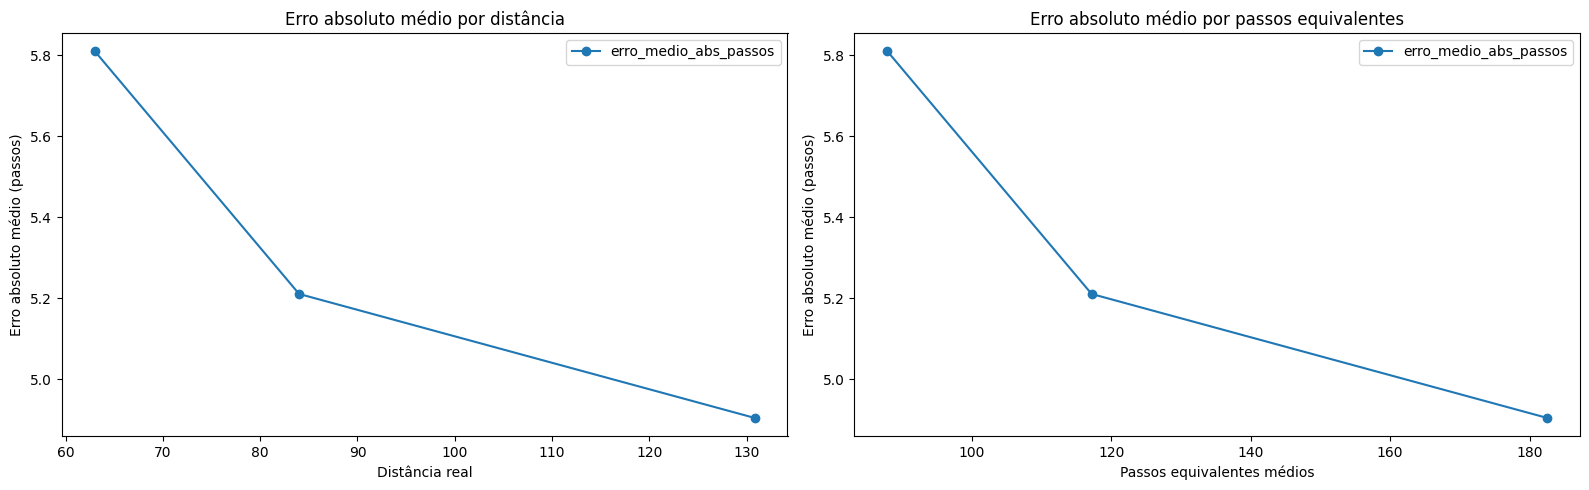

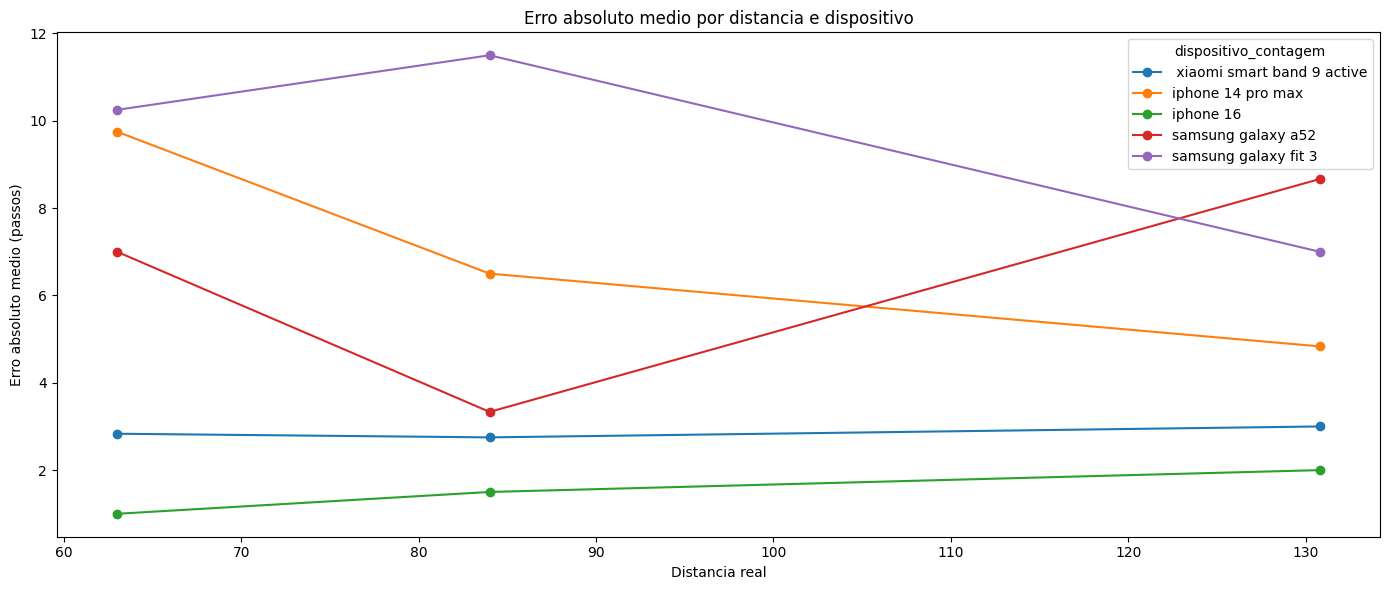

In [6]:
# Comparacao da precisao ao longo da distancia e da quantidade de passos equivalentes
base["faixa_passos_equivalentes"] = pd.cut(base["passos_equivalentes"], bins=5, include_lowest=True)

comparacao_por_distancia = (
    base.groupby("distancia_real")
    .agg(
        n_registros=("diferenca_abs_passos", "size"),
        passos_medio_manual=("contagem_manual", "mean"),
        erro_medio_abs_passos=("diferenca_abs_passos", "mean"),
        erro_medio_signed_passos=("diferenca_passos", "mean"),
        precisao_relativa_media_pct=("diferenca_abs_passos", lambda s: (1 - (s / base.loc[s.index, "contagem_manual"])).mean() * 100),
    )
    .reset_index()
    .sort_values("distancia_real")
)

comparacao_por_passos_equivalentes = (
    base.groupby("faixa_passos_equivalentes")
    .agg(
        n_registros=("diferenca_abs_passos", "size"),
        passos_equivalentes_medios=("passos_equivalentes", "mean"),
        passos_medio_manual=("contagem_manual", "mean"),
        erro_medio_abs_passos=("diferenca_abs_passos", "mean"),
        erro_medio_signed_passos=("diferenca_passos", "mean"),
        precisao_relativa_media_pct=("diferenca_abs_passos", lambda s: (1 - (s / base.loc[s.index, "contagem_manual"])).mean() * 100),
    )
    .reset_index()
)

# Correlacoes simples para indicar tendencia geral
correlacao_distancia_erro = base["distancia_real"].corr(base["diferenca_abs_passos"])
correlacao_passos_erro = base["passos_equivalentes"].corr(base["diferenca_abs_passos"])

print(f"Correlacao distancia x erro absoluto: {correlacao_distancia_erro:.3f}")
print(f"Correlacao passos_equivalentes x erro absoluto: {correlacao_passos_erro:.3f}")

display(comparacao_por_distancia)
display(comparacao_por_passos_equivalentes)

fig, axes = plt.subplots(1, 2, figsize=(16, 5))

comparacao_por_distancia.plot(
    x="distancia_real",
    y="erro_medio_abs_passos",
    kind="line",
    marker="o",
    ax=axes[0],
    title="Erro absoluto médio por distância",
)
axes[0].set_xlabel("Distância real")
axes[0].set_ylabel("Erro absoluto médio (passos)")

comparacao_por_passos_equivalentes.plot(
    x="passos_equivalentes_medios",
    y="erro_medio_abs_passos",
    kind="line",
    marker="o",
    ax=axes[1],
    title="Erro absoluto médio por passos equivalentes",
)
axes[1].set_xlabel("Passos equivalentes médios")
axes[1].set_ylabel("Erro absoluto médio (passos)")

plt.tight_layout()

# Comparacao por dispositivo ao longo da distancia real
comparacao_dispositivo_distancia = (
    base.groupby(["distancia_real", "dispositivo_contagem"])
    .agg(
        erro_medio_abs_passos=("diferenca_abs_passos", "mean"),
        precisao_relativa_media_pct=("diferenca_abs_passos", lambda s: (1 - (s / base.loc[s.index, "contagem_manual"])).mean() * 100),
    )
    .reset_index()
)

fig, ax = plt.subplots(figsize=(14, 6))
pivot_erro_dispositivo = comparacao_dispositivo_distancia.pivot(
    index="distancia_real",
    columns="dispositivo_contagem",
    values="erro_medio_abs_passos",
)
pivot_erro_dispositivo.plot(ax=ax, marker="o", title="Erro absoluto medio por distancia e dispositivo")
ax.set_xlabel("Distancia real")
ax.set_ylabel("Erro absoluto medio (passos)")
plt.tight_layout()

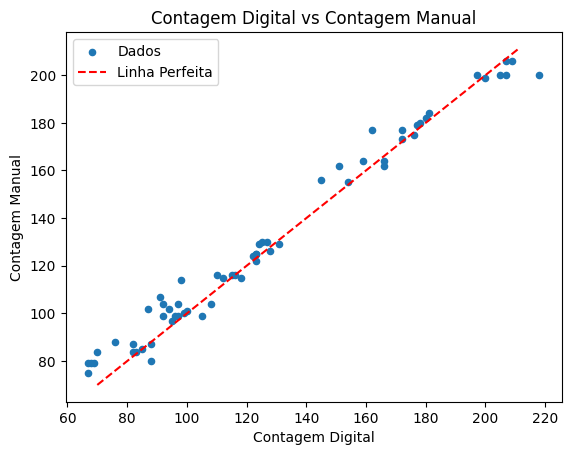

In [7]:
# plot scatter com uma linha "perfeita" em vermelho

adf.plot(x="contagem_digital", y="contagem_manual", kind="scatter", title="Contagem Digital vs Contagem Manual")
min_val = adf["contagem_manual"].min() - 5
max_val = adf["contagem_manual"].max() + 5
plt.plot([min_val, max_val], [min_val, max_val], color="red", linestyle="--")

# legenda do grafico
plt.xlabel("Contagem Digital")
plt.ylabel("Contagem Manual")
plt.legend(["Dados", "Linha Perfeita"])

Text(0, 0.5, 'Frequência')

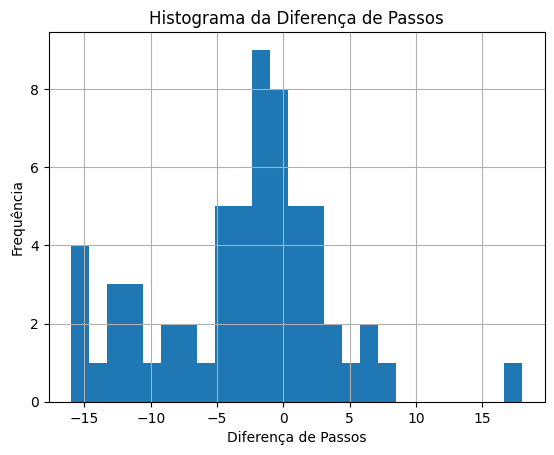

In [8]:
adf.hist(column="diferenca_passos", bins=25)


# fazer legendas do histograma
plt.title("Histograma da Diferença de Passos")
plt.xlabel("Diferença de Passos")
plt.ylabel("Frequência")

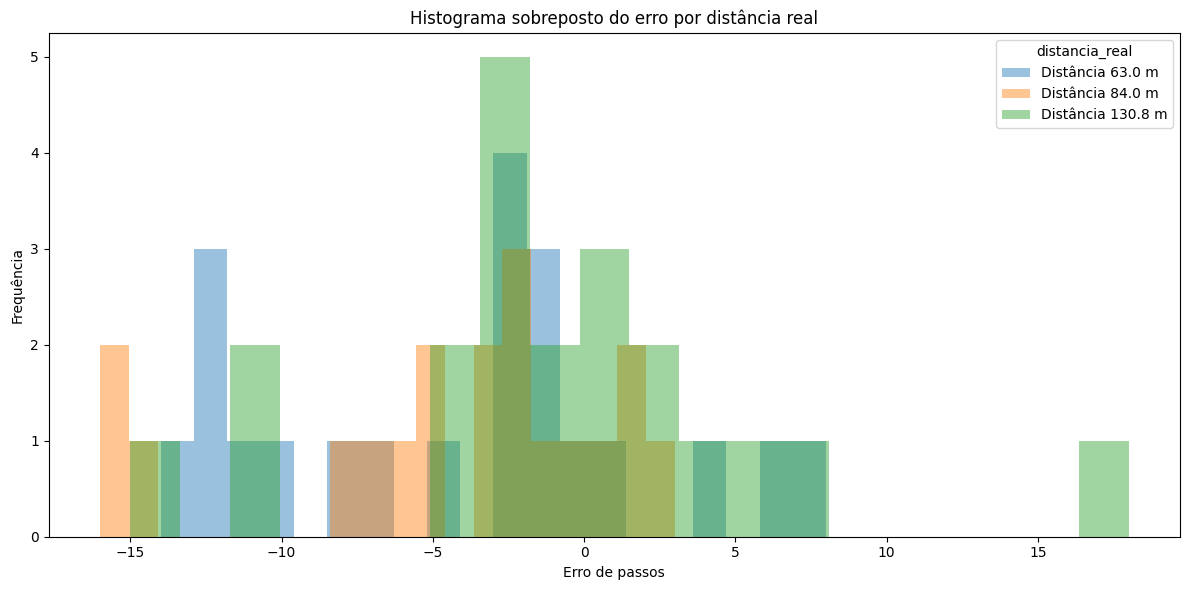

In [9]:
# Histograma sobreposto do erro absoluto por distancia_real
fig, ax = plt.subplots(figsize=(12, 6))

for distancia in sorted(adf["distancia_real"].dropna().unique()):
    dados_distancia = adf[adf["distancia_real"] == distancia]
    dados_distancia["diferenca_passos"].plot(
        kind="hist",
        bins=20,
        alpha=0.45,
        ax=ax,
        label=f"Distância {distancia} m",
    )

ax.set_title("Histograma sobreposto do erro por distância real")
ax.set_xlabel("Erro de passos")
ax.set_ylabel("Frequência")
ax.legend(title="distancia_real")
plt.tight_layout()

<Axes: xlabel='distancia_real', ylabel='contagem_manual'>

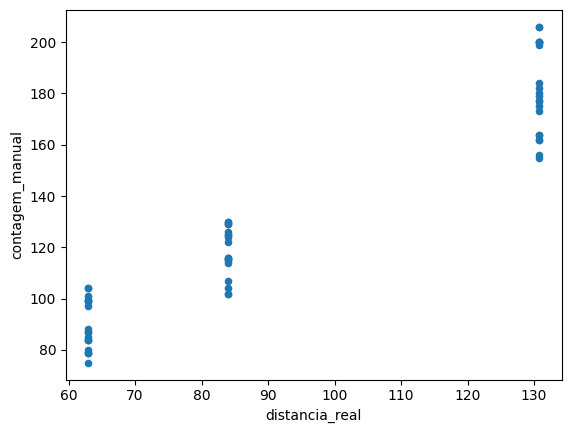

In [10]:
display(adf.plot(x="distancia_real", y="contagem_manual", kind="scatter"))

<Axes: title={'center': 'Erro médio por aplicativo'}, xlabel='aplicativo_contagem'>

<Axes: title={'center': 'Erro médio por dispositivo e aplicativo'}, xlabel='disp+app'>

<Axes: title={'center': 'Erro médio por distância real'}, xlabel='distancia_real'>

,distancia_real,diferenca_abs_passos
0,63.0,5.809524
1,84.0,5.210526
2,130.8,4.904762


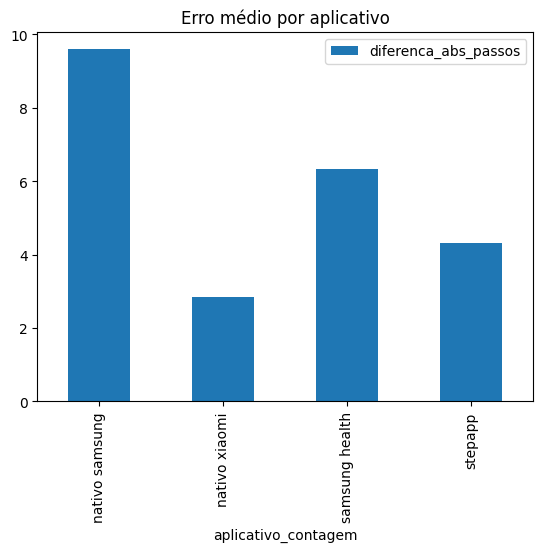

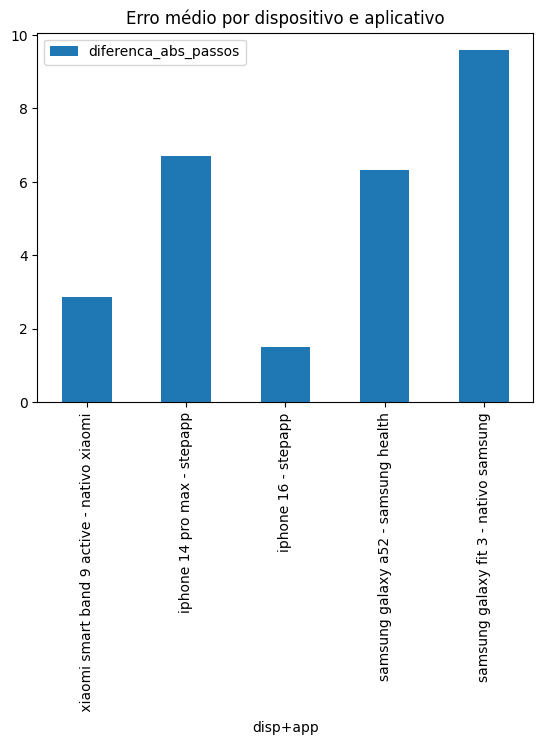

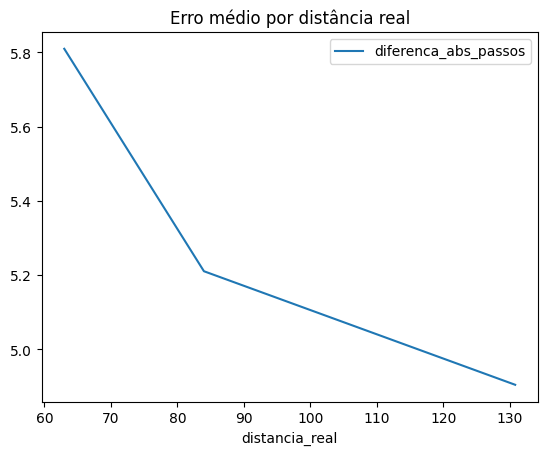

In [17]:
df_erro_medio_por_app = adf.groupby("aplicativo_contagem").agg({"diferenca_abs_passos": "mean"}).reset_index()
df_erro_medio_por_disp_e_app = adf.groupby("disp+app").agg({"diferenca_abs_passos": "mean"}).reset_index()
df_erro_medio_por_dist = adf.groupby("distancia_real").agg({"diferenca_abs_passos": "mean"}).reset_index()

display(df_erro_medio_por_app.plot(x="aplicativo_contagem", y="diferenca_abs_passos", kind="bar", title="Erro médio por aplicativo"))
display(df_erro_medio_por_disp_e_app.plot(x="disp+app", y="diferenca_abs_passos", kind="bar", title="Erro médio por dispositivo e aplicativo"))
display(df_erro_medio_por_dist.plot(x="distancia_real", y="diferenca_abs_passos", title="Erro médio por distância real"))

display(df_erro_medio_por_dist)

<Axes: title={'center': 'Erro médio por distância real e dispositivo/aplicativo'}, xlabel='distancia_real'>

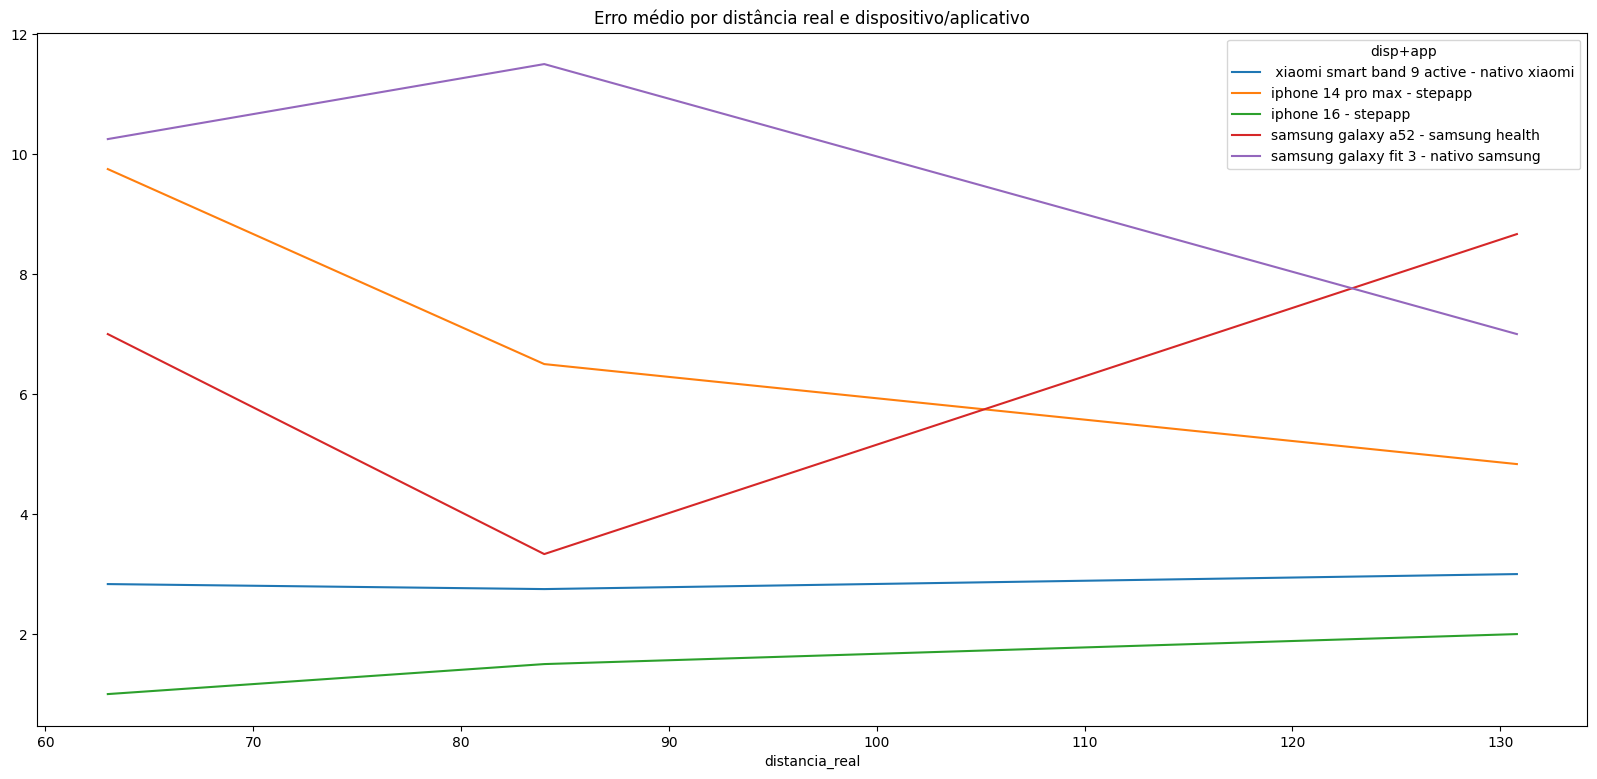

In [12]:
# plotar grafico de linha com uma linha de cada cor para cada disp+app, com eixo x sendo distancia_real e eixo y sendo diferenca_abs_passos
df_erro_medio_por_dist_por_disp_e_app = adf.groupby(["distancia_real", "disp+app"]).agg({"diferenca_abs_passos": "mean"}).reset_index()
display(
    df_erro_medio_por_dist_por_disp_e_app.pivot(index="distancia_real", columns="disp+app", values="diferenca_abs_passos").plot(
        title="Erro médio por distância real e dispositivo/aplicativo", figsize=(20, 9)
    )
)

In [16]:
tabela_precisao = (
    base.groupby('dispositivo_contagem')
    .agg(precisao_media_pct=('diferenca_abs_passos', lambda s: (1 - (s / base.loc[s.index, 'contagem_manual'])).mean() * 100))
    .reset_index()
    .sort_values(by='precisao_media_pct', ascending=False)
)

display(tabela_precisao["precisao_media_pct"].mean())
tabela_precisao['precisao_media_pct'] = tabela_precisao['precisao_media_pct'].map('{:.2f}%'.format)
display(tabela_precisao)

np.float64(95.26871003531134)

,dispositivo_contagem,precisao_media_pct
2,iphone 16,98.78%
0,xiaomi smart band 9 active,97.75%
3,samsung galaxy a52,95.40%
1,iphone 14 pro max,93.93%
4,samsung galaxy fit 3,90.48%
